In [82]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250m; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [83]:
# Reading Back Data Later
##############
def make_data_dict(in_file,var_names,read_type,start_job,end_job):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][start_job:end_job] for var_name in var_names}

            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][start_job:end_job].compute().data for k in var_names}

    return data_dict

# read_type='xarray'
read_type='h5py'

In [84]:
def GetData(data1,parcel1,start_job,end_job):
    #Indexing Array with JobArray
    data=data1.isel(time=slice(start_job,end_job))
    parcel=parcel1.isel(time=slice(start_job,end_job))
    return data,parcel
# [data,parcel]=GetData(data1,parcel1,start_job,end_job)

In [85]:
def GetSpatialData(data,start_job,end_job):
    import h5py
    dir2=dir+'Project_Algorithms/Lagrangian_Arrays/OUTPUT/'
    in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
    
    var_names = ['Z']#, 'Y', 'X']
    data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
    Z, = (data_dict[k] for k in var_names) #,Y,X
    
    # #Making Time Matrix
    Nt=len(data['time'])
    T = np.broadcast_to(np.arange(Nt)[:, None], Z.shape)  # shape: (Nt, p) #A_c==>Z
    
    # check_memory(globals())
    return T,Z#,Y,X

In [111]:
def GetAData(PROCESSING,start_job,end_job):
    if PROCESSING==False:
        dir2=dir+'Project_Algorithms/Lagrangian_Arrays/OUTPUT/'
        in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
        
        var_names = ['A_g', 'A_c']
        data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
        A_g, A_c = (data_dict[k] for k in var_names) #, W
    
    elif PROCESSING==True:
        dir2=dir+'Project_Algorithms/Entrainment/OUTPUT/'
        in_file=dir2+f'processed_binary_arrays_{res}_{t_res}_{Np_str}.h5'
        
        var_names = ['A_g_Processed', 'A_c_Processed']
        data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
        A_g,A_c = (data_dict[k] for k in var_names)
        # check_memory(globals())
    return A_g,A_c

In [112]:
# def GetAPrior(PROCESSING,start_job): #FIX FOR JOB_ARRAY (SO FIRST TIMESTEP WILL NOT BE BLANK)
#     if start_job!=0:
#         A_g_Prior,A_c_Prior=GetAData(PROCESSING,start_job-1,start_job);
#         return A_g_Prior,A_c_Prior
#     else:
#         return 0,0
# def GetAPost(PROCESSING,end_job): #*#*
#     if end_job!=len(data1['time']):
#         [A_g_Post,A_c_Post]=GetAData(PROCESSING,end_job-1,end_job+1)
#         return A_g_Post,A_c_Post
#     else:
#         return 0,0
# def FixDetrainment(A1_Post,A2_Post): #*#*
#     #when using slurm_job_array, last timestep is not calculated
#     #since data is outside of access scope
#     #THIS FUNCTION FIXES THAT
#     D3 = np.zeros_like(A2_Post,dtype=np.int8)
#     D3[1:, :] = A2_Post[1:, :]*1 + A1_Post[:-1, :]*1
#     return D3[1:]

In [113]:
# def SubtractA(A,A_Prior):
#     D = np.zeros_like(A,dtype=np.int8)
#     D[1:, :] = A[1:, :]*1 - A[:-1, :]*1
#     if start_job!=0:
#         D[0, :] = A[0, :]*1-A_Prior*1 #FIX FOR FIRST TIMESTEP
#     return D

# def AddAs(A1,A2,A1_Prior):
#     S = np.zeros_like(A2,dtype=np.int8)
#     S[1:, :] = A2[1:, :]*1 + A1[:-1, :]*1
#     if start_job!=0:
#         S[0, :] = A2[0, :]*1 + A1_Prior*1 #FIX FOR FIRST TIMESTEP
#     return S

# def S_2d(data, A1,A2, T, Z, A1_Prior,A1_Post,A2_Post, type1): #*#*
#     # start_time = time.time()
    
#     #calculating entrainment going from general <==> cloudy updrafts
#     S=AddAs(A1,A2,A1_Prior) #General <==> Cloudy
#     cond=(S==2) #must be either entrained OR detrained from/to environment) AND (NOT move between general and cloudy updrafts) 
#     D = cond*1 #converting to 1s and 0s

#     #MAKING DETRAINMENT VERSION (SAME BUT STORED AT PREVIOUS TIMESTEP)
#     if type1=='d':
#         D2=np.zeros_like(D); D2[:-1]= D[1:]; D=D2.copy() #NEED TO SHIFT TO PREVIOUS TIME TO STORE D CORRECTLY 
#         if not isinstance(A2_Post, int): D3=FixDetrainment(A1_Post,A2_Post);D[-1]=D3.copy(); #*#*

#     # Initialize time and vertical dimension arrays
#     Nt = len(data['time']); Nz = len(data1['zh'])
#     # Initialize result array
#     result = np.zeros((Nt, Nz))

#     # Use np.add.at to accumulate values in the result array
#     np.add.at(result, (T, Z), D)

#     # end_time = time.time()
#     # print(f"Execution time: {(end_time - start_time)} seconds")
#     return result

In [89]:
###########################################
#LOADING DATA

In [90]:
PROCESSING=True
if res=='1km' and Np_str=='1e6':
    start_job=100
    end_job=110
elif res=='1km' and Np_str=='50e6':
    start_job=500
    end_job=510
# start_job=0;end_job=len(data1['time'])

[A_g,A_c]=GetAData(PROCESSING, start_job, end_job)
data,parcel=GetData(data1,parcel1,start_job,end_job)
[T,Z]=GetSpatialData(data,start_job,end_job)

In [91]:
#######################################
#GENERAL to CLOUDY ENTRAINMENT
A1=A_g.copy()
A2=A_c.copy()
A=A2.copy()

In [92]:
#CALCULATION
S = np.zeros_like(A2,dtype=np.int8)
S[1:, :] = A2[1:, :]*1 + A1[:-1, :]*1
cond=(S==2)
D1=cond*1

#INDEXING
# Initialize time and vertical dimension arrays
Nt = len(data['time']); Nz = len(data1['zh'])
# Initialize result array
result1= np.zeros((Nt, Nz))
# Use np.add.at to accumulate values in the result array
np.add.at(result1, (T, Z), D1)

In [93]:
#######################################
#CLOUDY ENTRAINMENT

In [94]:
#CALCULATION
type='e'
D = np.zeros_like(A,dtype=np.int8)
D[1:, :] = A[1:, :]*1 - A[:-1, :]*1

if type=='e':
    D[D < 0] = 0
elif type=='d':
    D[D > 0] = 0

#INDEXING
# Initialize time and vertical dimension arrays
Nt = len(data['time']); Nz = len(data1['zh'])
# Initialize result array
result2= np.zeros((Nt, Nz))
# Use np.add.at to accumulate values in the result array
np.add.at(result2, (T, Z), D)

In [95]:
#######################################
#RATIO

/tmp/ipykernel_3941349/3496847022.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio1 = result1 / result2
/tmp/ipykernel_3941349/3496847022.py:1: RuntimeWarning: invalid value encountered in divide
  ratio1 = result1 / result2


Text(0, 0.5, 'Number')

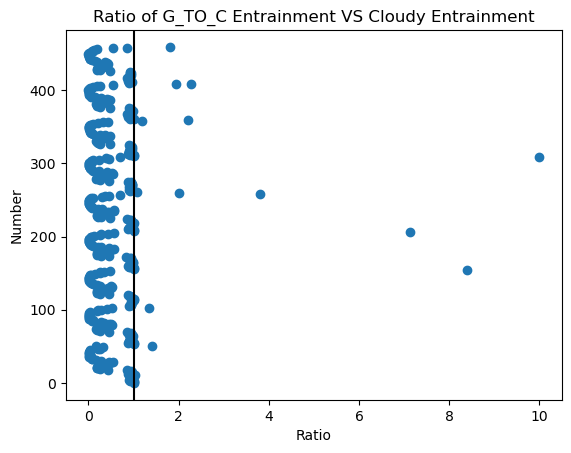

In [140]:
ratio1 = result1 / result2
ratio = ratio1.flatten()

# Remove NaNs
mask = ~np.isnan(scat)
ratio_clean = ratio[mask]
y = np.arange(len(ratio_clean))

plt.scatter(ratio_clean, y)
plt.axvline(1, color='k')
plt.title('Ratio of G_TO_C Entrainment VS Cloudy Entrainment')
plt.xlabel('Ratio');plt.ylabel("Number")

(array([1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8,
       9, 9]), array([39, 79, 80, 79, 80, 38, 39, 79, 80, 79, 80, 39, 79, 80, 30, 31, 79,
       31, 78, 79, 78, 79, 79, 80]))


Text(0.5, 1.0, 'Plot of Height Where RATIO>1')

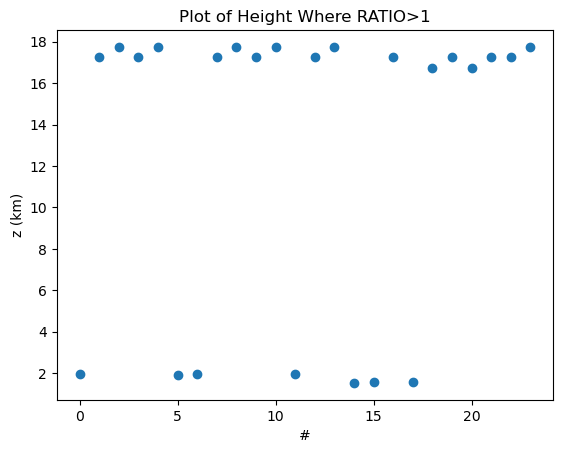

In [142]:
where=np.where(scat1>1)
print(where) #OCCURS OVER ALL TIMESTEPS

x=data['zh'][where[1]];y=np.arange(len(x))
plt.scatter(y,x)
plt.ylabel('z (km)'); plt.xlabel('#')
plt.title('Plot of Height Where RATIO>1')

In [115]:
##############################
#COMPARING THE TWO

In [122]:
test=D[np.where(D1!=0)] #IF TEST IS 0, THEN G_TO_C Entrainment has no Cloudy Entrainment counterpart

In [128]:
len(test[test==0])*100/( len(test[test==1])+len(test[test==0]) ) 
#==> about 20% of all G_TO_C Entrainment has no Cloudy Entrainment Counterpart

19.509408969661617

In [ ]:
#*#* (MAY NEED TO CORRECT BOUNDARIES LATER)